# Leveraging Open Data and Models to Reduce Aviation's Climate Footprint

This notebook is a companion to the ISA Research School lecture slides. It collects the lecture code examples in one place, with short explanations between sections.

The notebook is designed to execute in the repository environment. Cells that normally require live services or large external datasets include the real code path and a local fallback so the rendered notebook still shows meaningful output.

## 1. Setup

Import the plotting and data packages used throughout the examples. The helper functions live in `scripts/isa_demo.py`, so the notebook adds that folder to Python's import path.

In [1]:
from pathlib import Path
import sys

PROJECT = Path.cwd()
SCRIPTS = PROJECT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from IPython.display import Image, Markdown, display
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

## 2. Load the Cached OpenSky Example Flight

The lecture uses one cached A319 trajectory. It gives a concrete flight for trajectory inspection, OpenAP fuel and emissions estimation, and later contrail examples.

In [2]:
from isa_demo import load_sample_flight

flight = load_sample_flight()
flight[["timestamp", "typecode", "origin", "destination", "latitude", "longitude", "altitude"]].head()

,timestamp,typecode,origin,destination,latitude,longitude,altitude
0,2018-01-02 19:53:00+00:00,a319,LBG,BMA,49.085861,2.349666,8200.0
1,2018-01-02 19:54:00+00:00,a319,LBG,BMA,49.153427,2.310861,9475.0
2,2018-01-02 19:55:00+00:00,a319,LBG,BMA,49.233367,2.361121,9975.0
3,2018-01-02 19:56:00+00:00,a319,LBG,BMA,49.319916,2.418471,11225.0
4,2018-01-02 19:57:00+00:00,a319,LBG,BMA,49.411652,2.478896,14175.0


In [3]:
flight.shape, flight.timestamp.min(), flight.timestamp.max()

((116, 15),
 Timestamp('2018-01-02 19:53:00+0000', tz='UTC'),
 Timestamp('2018-01-02 21:48:00+0000', tz='UTC'))

In [4]:
flight.phase.value_counts()

phase
level      80
climb      20
descent    16
Name: count, dtype: int64

## 3. OpenSky Access Patterns with pyopensky

These are the live and historical access patterns used in the lecture. If `pyopensky` is not installed or credentials are not configured, the cell renders the intended code path without making a live query.

In [5]:
try:
    from pyopensky.rest import REST

    rest = REST()
    states = rest.states()
    track = rest.tracks(icao24="3c6444")
    display(states.head())
except Exception as exc:
    display(Markdown(
        "`pyopensky` live REST query was not executed in this environment. "
        f"Reason: `{type(exc).__name__}: {exc}`"
    ))

`pyopensky` live REST query was not executed in this environment. Reason: `ModuleNotFoundError: No module named 'pyopensky'`

In [6]:
try:
    from pyopensky.trino import Trino

    trino = Trino()
    flights = trino.flightlist(
        start="2024-06-01",
        stop="2024-06-02",
        airport="EHAM",
    )

    states = trino.history(
        start="2024-06-01 12:00",
        stop="2024-06-01 13:00",
        bounds=(3.0, 7.5, 50.0, 54.0),
    )
    display(flights.head())
except Exception as exc:
    display(Markdown(
        "`pyopensky` historical Trino query was not executed in this environment. "
        f"Reason: `{type(exc).__name__}: {exc}`"
    ))

`pyopensky` historical Trino query was not executed in this environment. Reason: `ModuleNotFoundError: No module named 'pyopensky'`

## 4. Inspect the Trajectory

Plot the lateral path on a map projection and the vertical profile of the same trajectory. This is the flight reused in the performance and emissions section.

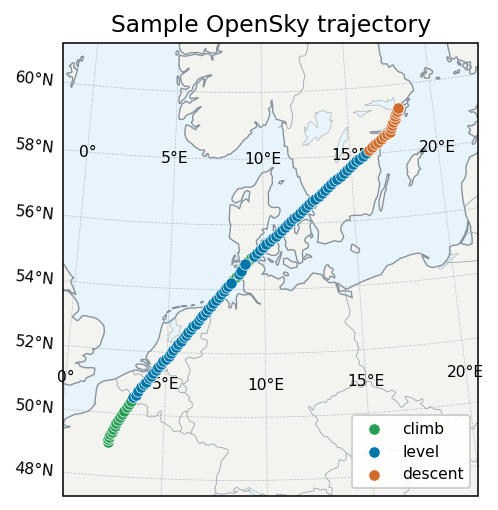

In [7]:
from isa_demo import plot_trajectory

plot_trajectory(flight)

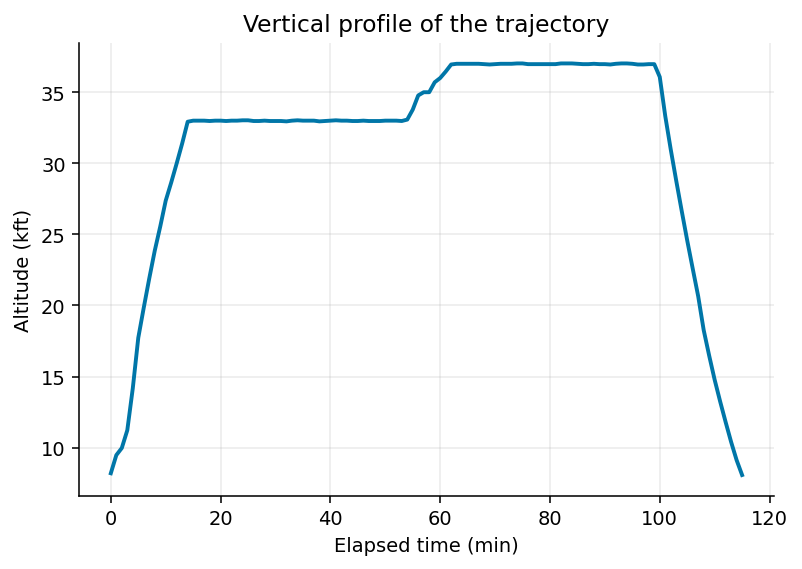

In [8]:
from isa_demo import plot_vertical_profile

plot_vertical_profile(flight)

## 5. OpenAP Aircraft Model Inputs

OpenAP exposes the aircraft record used by its performance model. The mass limits, aerodynamic coefficients, engine, and fuel coefficients are the inputs behind fuel burn and emissions estimates.

In [9]:
import openap

aircraft = openap.prop.aircraft("A319")
aircraft

{'aircraft': 'Airbus A319',
 'mtow': 75500,
 'mlw': 62500,
 'oew': 40800,
 'mfc': 30190,
 'vmo': 350,
 'mmo': 0.82,
 'ceiling': 12500,
 'pax': {'max': 156, 'low': 110, 'high': 140},
 'fuselage': {'length': 33.84, 'height': 4.14, 'width': 3.95},
 'wing': {'area': 124, 'span': 35.8, 'mac': 4.1935, 'sweep': 25, 't/c': None},
 'flaps': {'type': 'single-slotted',
  'area': 21.1,
  'bf/b': 0.78,
  'lambda_f': 0.9,
  'cf/c': 0.176,
  'Sf/S': 0.17},
 'cruise': {'height': 11000, 'mach': 0.78, 'range': 3300},
 'engine': {'type': 'turbofan',
  'mount': 'wing',
  'number': 2,
  'default': 'V2524-A5',
  'options': {'A319-111': 'CFM56-5B5',
   'A319-112': 'CFM56-5B6',
   'A319-113': 'CFM56-5A4',
   'A319-114': 'CFM56-5A5',
   'A319-115': 'CFM56-5B7',
   'A319-131': 'V2522-A5',
   'A319-132': 'V2524-A5',
   'A319-133': 'V2527M-A5'}},
 'drag': {'cd0': 0.02, 'k': 0.039, 'e': 0.783, 'gears': 0.017},
 'fuel': {'engine': 'V2524-A5', 'fuel_coef': 2.33357287},
 'limits': {'MTOW': 75500,
  'MLW': 62500,
  'O

## 6. Fuel and Emissions Along One Trajectory

This cell keeps the OpenAP calls visible. For each trajectory point, it computes en-route fuel flow, converts fuel flow to segment fuel burn, and estimates CO2 and NOx emissions for the same segment.

In [10]:
import pandas as pd
import openap

fuelflow = openap.FuelFlow("A319")
emission = openap.Emission("A319")

mass = 62_000.0
rows = []

for point in flight.itertuples(index=False):
    ff = float(
        fuelflow.enroute(
            mass=mass,
            tas=point.groundspeed,
            alt=point.altitude,
            vs=float(point.vertical_rate),
        )
    )
    fuel = ff * point.dt_s
    rows.append(
        {
            "fuel_flow_kg_s": ff,
            "fuel_kg": fuel,
            "co2_kg": float(emission.co2(ff) * point.dt_s / 1000.0),
            "nox_g": float(
                emission.nox(
                    ff,
                    tas=point.groundspeed,
                    alt=point.altitude,
                )
                * point.dt_s
            ),
        }
    )
    mass -= fuel

flight_perf = flight.join(pd.DataFrame(rows, index=flight.index))
flight_perf["mass_kg"] = 62_000 - flight_perf["fuel_kg"].cumsum()
flight_perf[["elapsed_min", "altitude", "groundspeed", "fuel_flow_kg_s", "fuel_kg", "co2_kg", "nox_g"]].head()

,elapsed_min,altitude,groundspeed,fuel_flow_kg_s,fuel_kg,co2_kg,nox_g
0,0.0,8200.0,255.0,1.445910,86.754630,274.144630,1604.411907
1,1.0,9475.0,290.0,1.080693,64.841556,204.899317,971.669363
2,2.0,9975.0,332.0,1.014561,60.873660,192.360765,877.380513
3,3.0,11225.0,353.0,1.560502,93.630148,295.871266,1910.257630
4,4.0,14175.0,368.0,1.643420,98.605174,311.592351,2158.986260


Summarize the total fuel, CO2, and NOx estimates for the example flight.

In [11]:
totals = flight_perf[["fuel_kg", "co2_kg", "nox_g"]].sum()
totals.round(1)

fuel_kg     4789.0
co2_kg     15133.4
nox_g      60650.1
dtype: float64

Plot fuel flow, cumulative fuel, CO2 rate, and NOx rate along the trajectory.

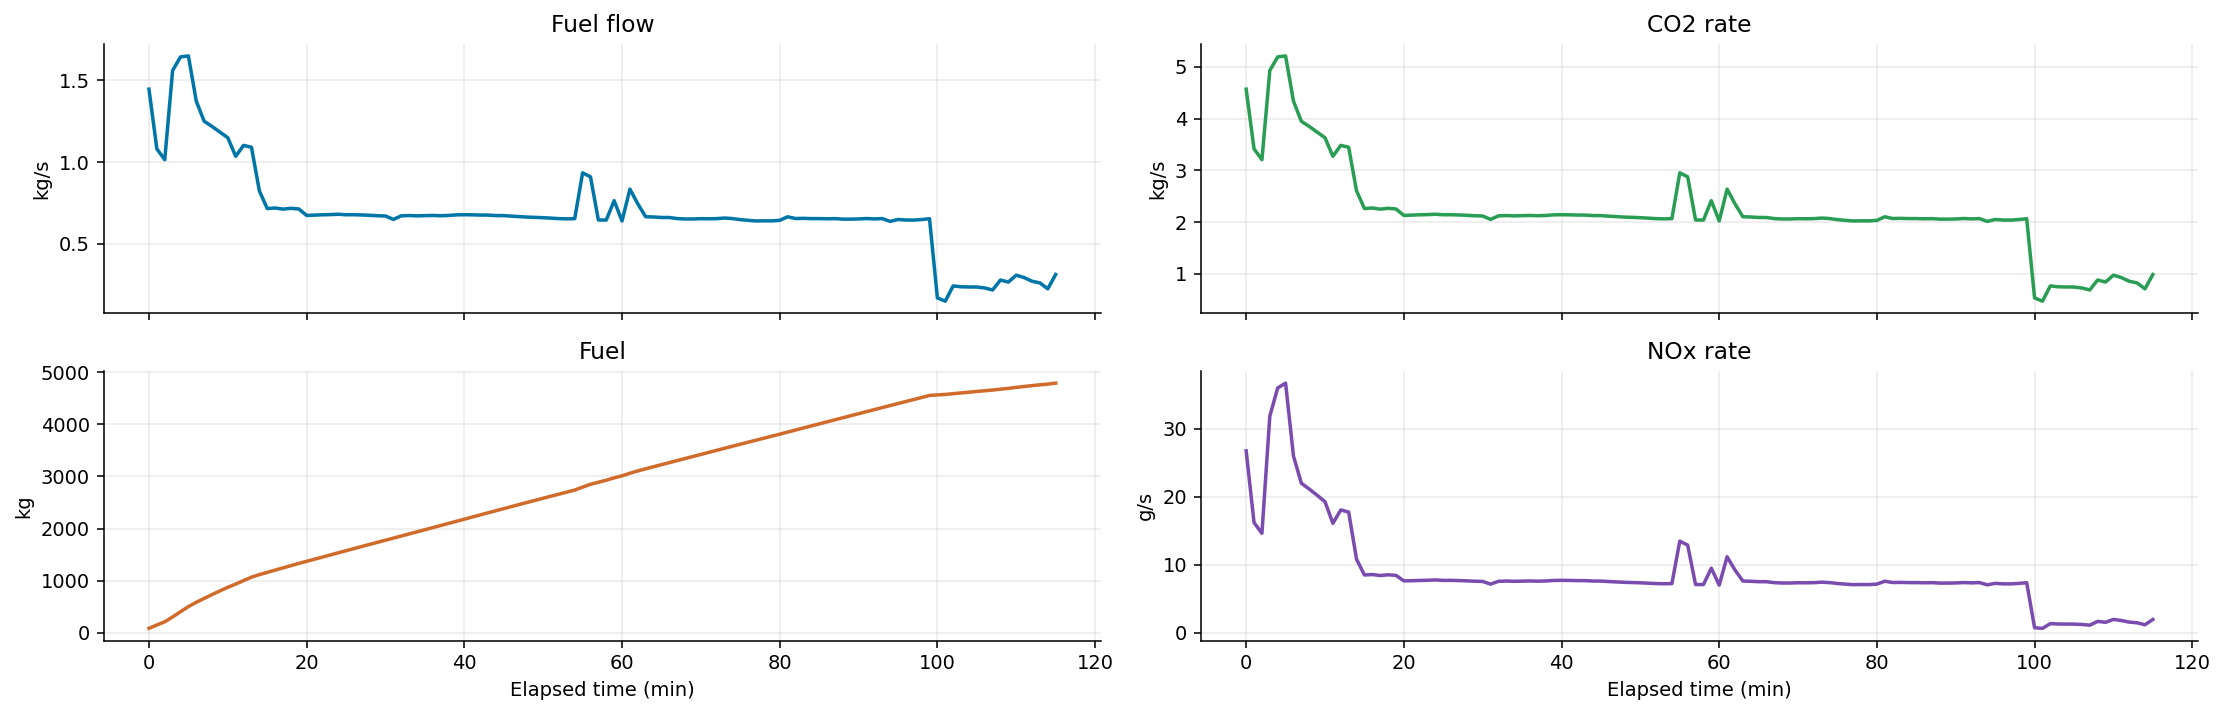

In [12]:
from isa_demo import plot_emission_timeseries

plot_emission_timeseries(flight_perf)

## 7. Add Real Weather with FastMeteo

The lecture uses FastMeteo to interpolate weather fields onto trajectory points. In a fully configured environment, the code below uses `ArcoEra5`. In this rendered notebook, if `fastmeteo` is unavailable or no local ERA5 store exists, the cell shows the input flight and the saved figure from the FastMeteo paper workflow.

FastMeteo interpolation was not executed in this environment. Reason: `ModuleNotFoundError: No module named 'fastmeteo'`

,timestamp,icao24,typecode,callsign,origin,destination,latitude,longitude,altitude,groundspeed,track,vertical_rate
0,2018-01-02 19:53:00+00:00,3.946000e+12,a319,AFR91HL,LBG,BMA,49.085861,2.349666,8200.0,255.0,327.804266,1920.0
1,2018-01-02 19:54:00+00:00,3.946000e+12,a319,AFR91HL,LBG,BMA,49.153427,2.310861,9475.0,290.0,9.722018,960.0
2,2018-01-02 19:55:00+00:00,3.946000e+12,a319,AFR91HL,LBG,BMA,49.233367,2.361121,9975.0,332.0,23.243919,640.0
3,2018-01-02 19:56:00+00:00,3.946000e+12,a319,AFR91HL,LBG,BMA,49.319916,2.418471,11225.0,353.0,23.517962,2752.0
4,2018-01-02 19:57:00+00:00,3.946000e+12,a319,AFR91HL,LBG,BMA,49.411652,2.478896,14175.0,368.0,23.566915,3584.0


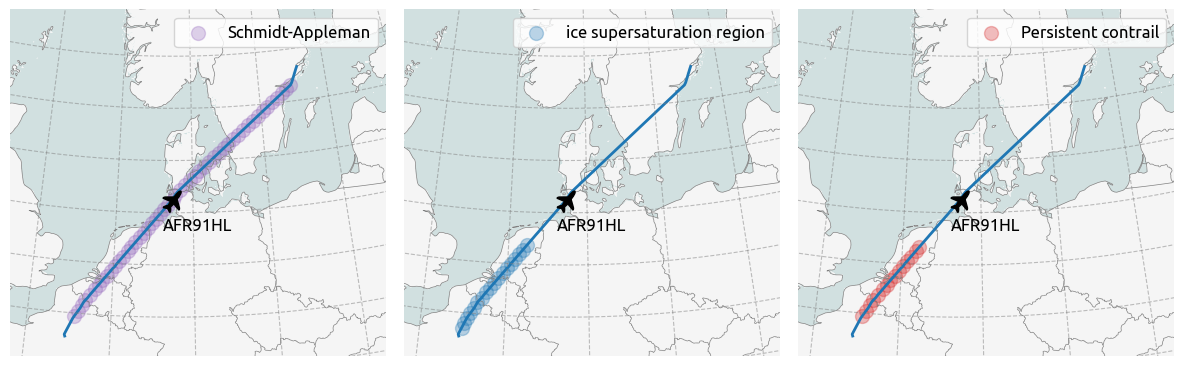

In [13]:
flight_weather_input = pd.read_csv(
    "assets/fastmeteo_example_flight.csv",
    parse_dates=["timestamp"],
)

try:
    from fastmeteo.source import ArcoEra5

    era5 = ArcoEra5(local_store="/tmp/era5-zarr")
    flight_weather = era5.interpolate(flight_weather_input)
    display(flight_weather.head())
except Exception as exc:
    display(Markdown(
        "FastMeteo interpolation was not executed in this environment. "
        f"Reason: `{type(exc).__name__}: {exc}`"
    ))
    display(flight_weather_input.head())
    display(Image(filename="assets/fastmeteo_paper_cell_9.png"))

## 8. Diagnose Persistent Contrail Regions with OpenAP

Once weather variables are interpolated onto the trajectory, OpenAP's contrail utilities compute relative humidity over ice, the Schmidt-Appleman criterion, ice supersaturation, and persistent-contrail flags.

Contrail diagnosis needs the weather-enriched trajectory from section 7. Reason: `NameError: name 'flight_weather' is not defined`

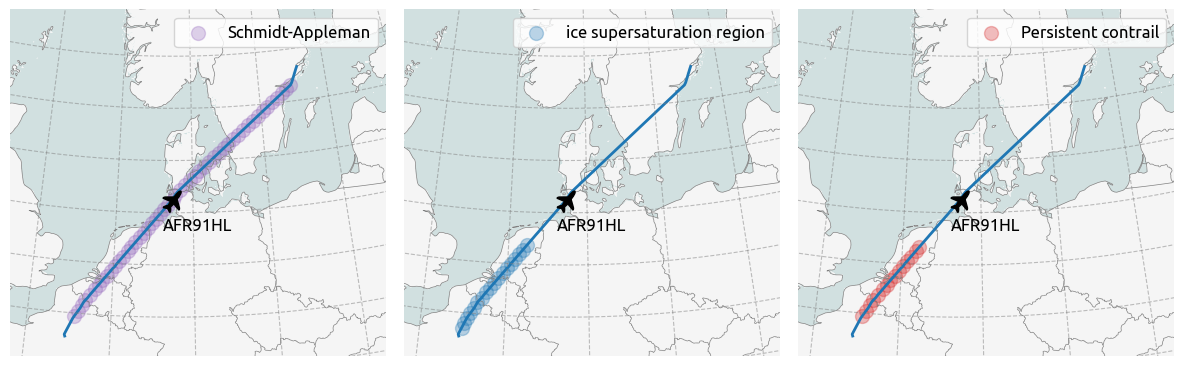

In [14]:
from openap import aero, contrail

try:
    flight_contrail = flight_weather.assign(
        rhi=lambda d: contrail.relative_humidity(
            d.specific_humidity,
            aero.pressure(d.altitude * aero.ft),
            d.temperature,
            to="ice",
        ),
        crit_temp=lambda d: contrail.critical_temperature_water(
            aero.pressure(d.altitude * aero.ft)
        ),
        sac=lambda d: d.temperature < d.crit_temp,
        issr=lambda d: d.rhi > 1,
        persistent=lambda d: d.sac & d.issr,
    )

    display(
        flight_contrail[
            ["timestamp", "altitude", "temperature", "rhi", "sac", "issr", "persistent"]
        ].head()
    )
except Exception as exc:
    display(Markdown(
        "Contrail diagnosis needs the weather-enriched trajectory from section 7. "
        f"Reason: `{type(exc).__name__}: {exc}`"
    ))
    display(Image(filename="assets/fastmeteo_paper_cell_9.png"))

## 9. Climate Objective in opentop

The full optimization is too heavy for a lecture render, but this cell keeps the objective structure visible. A weather-derived contrail cost grid is interpolated along candidate trajectories and balanced against CO2 from fuel burn. If `opentop` or `df_cost` is unavailable, the cell renders the figures used in the optimization section.

The opentop optimization cell was not solved in this environment. Reason: `ModuleNotFoundError: No module named 'opentop'`

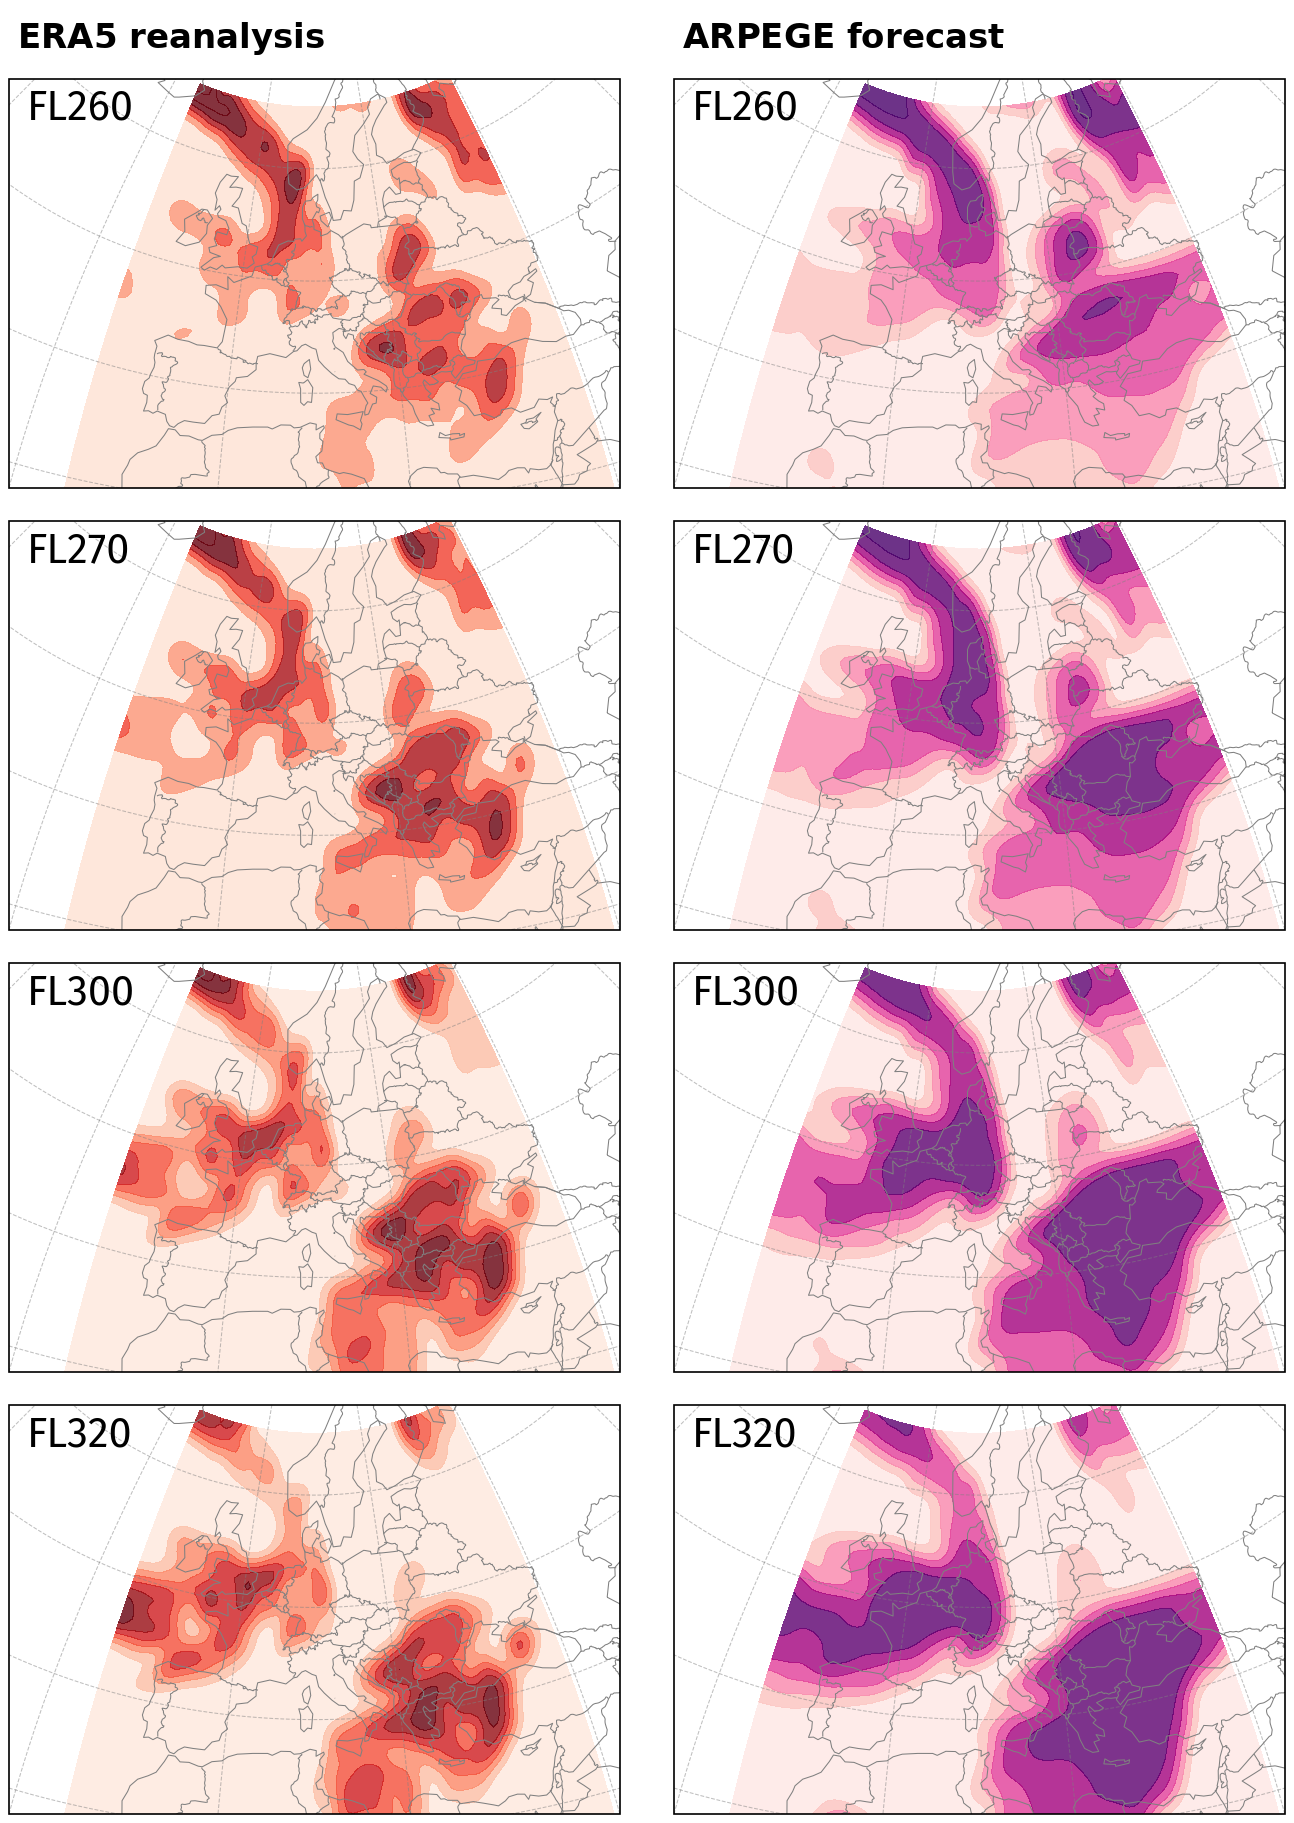

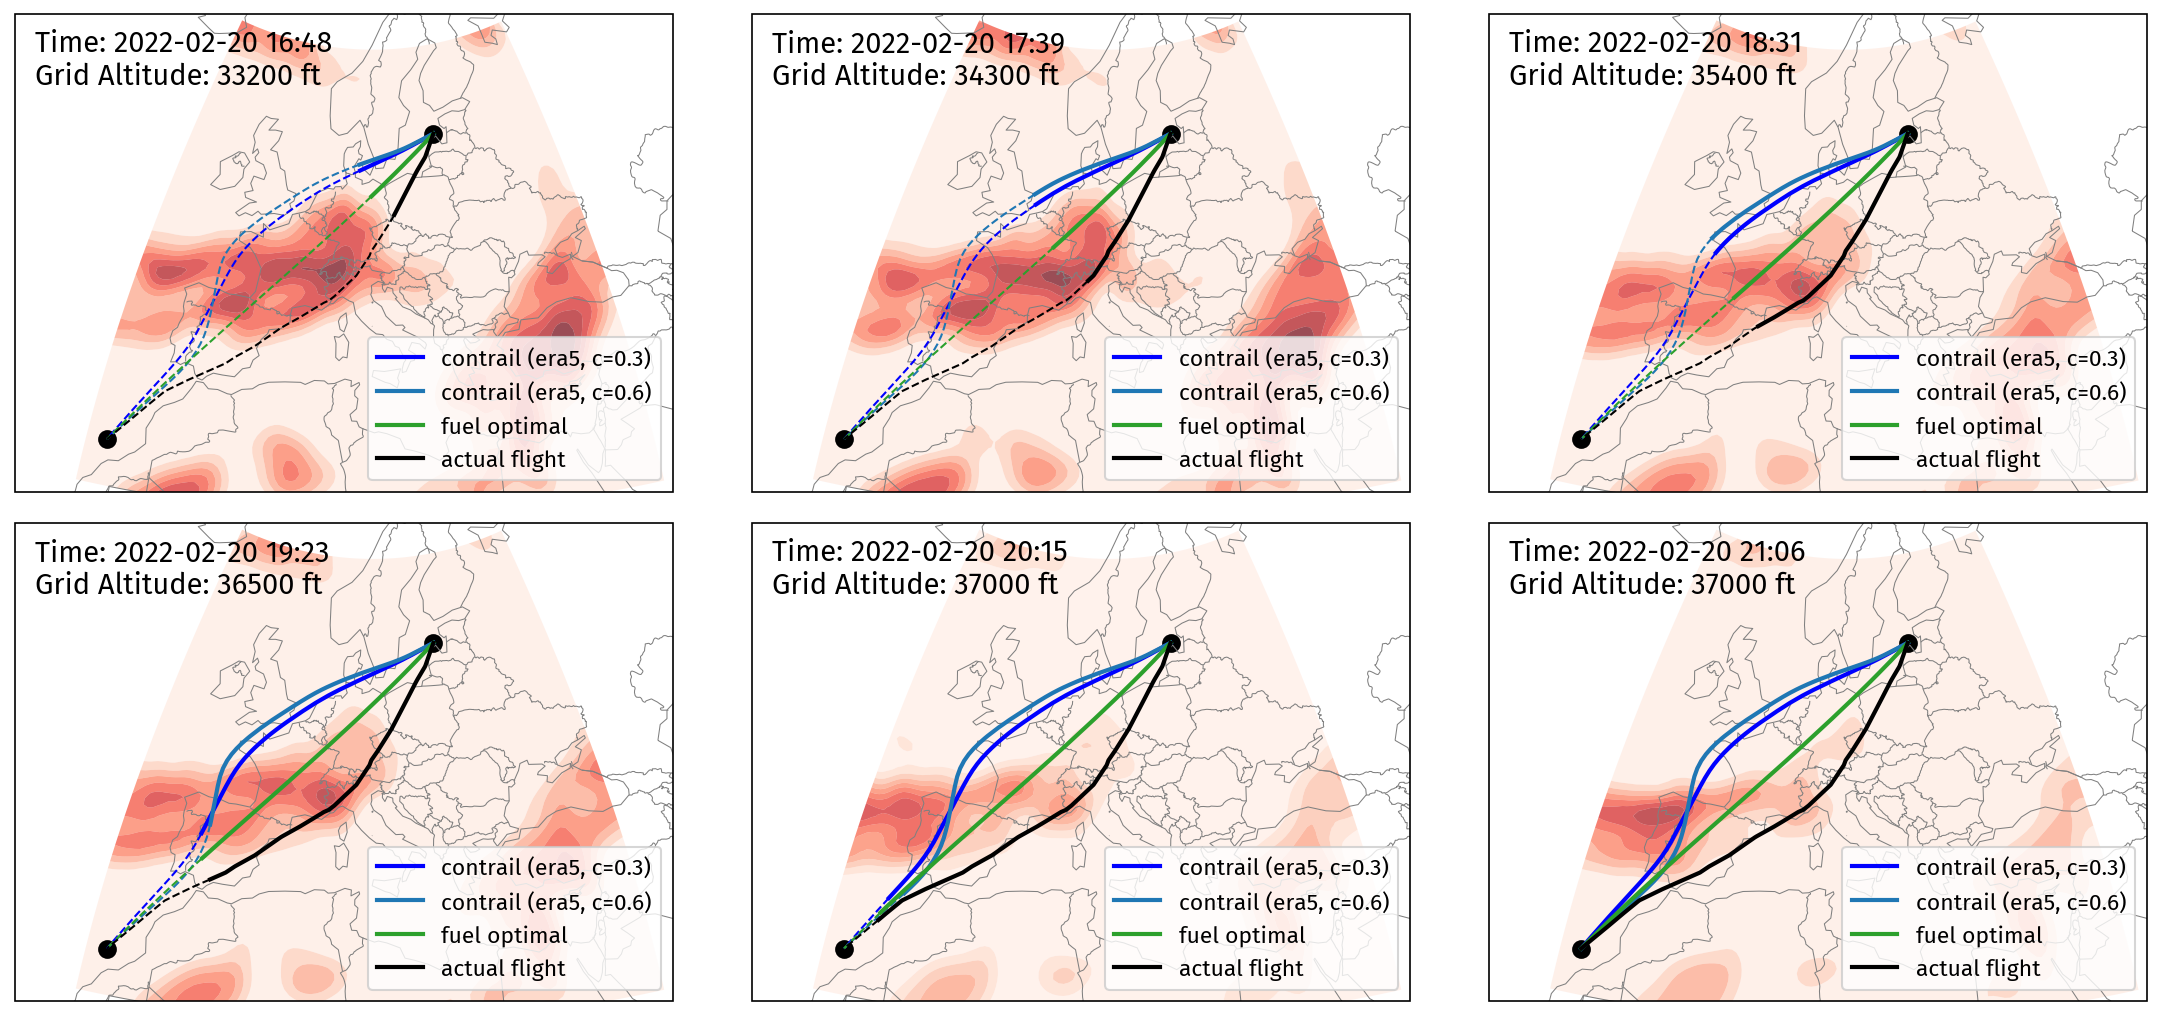

In [15]:
try:
    import opentop as top

    optimizer = top.Cruise("A320", "EHAM", "LGAV", m0=0.85)
    flight_fuel_optimal = optimizer.trajectory(objective="fuel")
    interpolant = top.tools.interpolant_from_dataframe(df_cost)

    def objective(x, u, dt, **kwargs):
        vtas = openap.casadi.aero.mach2tas(u[0], x[2])
        contrail_cost = optimizer.obj_grid_cost(
            x, u, dt, n_dim=3, time_dependent=False, **kwargs
        ) * vtas * 1e-3
        co2_cost = optimizer.obj_fuel(x, u, dt, **kwargs) * 7.03e-15
        return contrail_cost + co2_cost

    display(flight_fuel_optimal.head())
except Exception as exc:
    display(Markdown(
        "The opentop optimization cell was not solved in this environment. "
        f"Reason: `{type(exc).__name__}: {exc}`"
    ))
    display(Image(filename="assets/contrail_paper_cost_grid_pair.png"))
    display(Image(filename="assets/contrail_paper_q1_trajectories.png"))

## 10. Suggested Exercises

1. Change the assumed takeoff mass and compare fuel and emissions totals.
2. Replace `A319` with another OpenAP-supported aircraft type and inspect which aircraft parameters change.
3. Run the FastMeteo cell with a configured ERA5 store and compare the contrail flags against the static figure in the slides.
4. Modify the opentop objective weighting to reason about fuel-versus-contrail trade-offs.